[강의안]
1. 차분: 두 픽셀 값 차이 계산 (변화 -> 차분)
```
1. 공간적 차분(x,y): 인접한 픽셀 간의 차이 계산
2. 시간적 차분(x,y,t): 시간 순서가 있는 영상에서 연속된 프레임 간의 차이 계산(움직임 검출)
```

2. 특징 종류
```
1. 저수준(low-level) 특징 : 색, 밝기, 강도intensity, edge, corner, blob(무늬)
2. 중간 수준(mid-level): 윤곽선, 질감, 형태 기술자(삼각형/사각형..)
3. 고수준(high-level) 특징 : 지역적 특징(눈,코,입), 딥러닝 기반 특징

3. 엣지 검출
```
1. 소벨 필터 : 미분 + 평활화 (미분만 하면 노이즈 민감)
2. 캐니 엣지 : 노이즈 억제 + 정확한 엣지 검출 + 단일 엣지 추출
- 캐니 엣지 단계: 5단계
3. Hough Transform(허프 변환) : 점에서 기하학적 도형 탐지, image space->parameter space

```
캐니 엣지 5단계
1. 노이즈 제거(Gaussian Blur)
2. 그래디언트 계산(Sobel Filter)
3. 비최대 억제(Non-Maximum Suppression) : 엣지의 방향을 따라 로컬의 최댓값만 남기고 나머지는 억제
4. 이중 임계값 처리(Double Thresholding) : 강한 엣지, 약한 엣지를 파악하여 약한 엣지는 강한 엣지와 연결되었을 때만 보존
5. 강한 엣지와 연결되지 않은 약한 엣지는 제거

```

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [ ]:
image_path = '/content/drive/MyDrive/rokey/AI/application/3/unnamed.jpg'

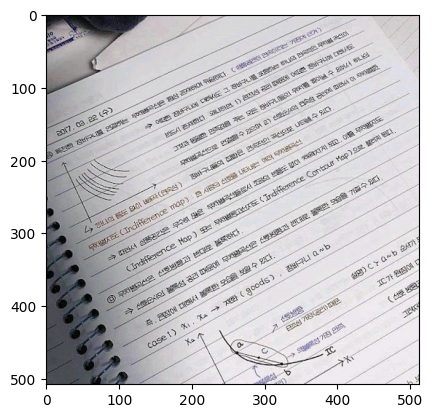

In [ ]:
image = cv2.imread(image_path)
plt.imshow(image)

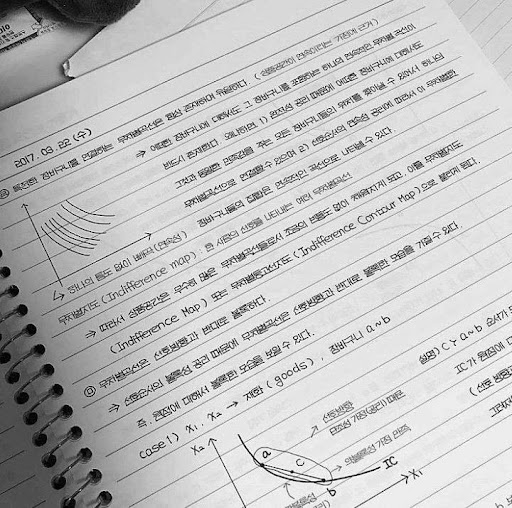

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

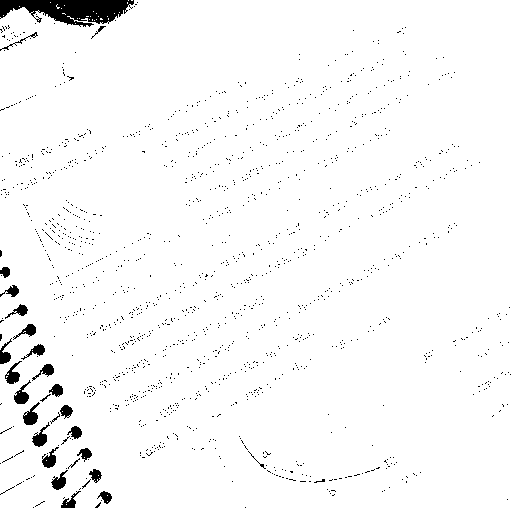

In [ ]:
result, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
cv2_imshow(binary)

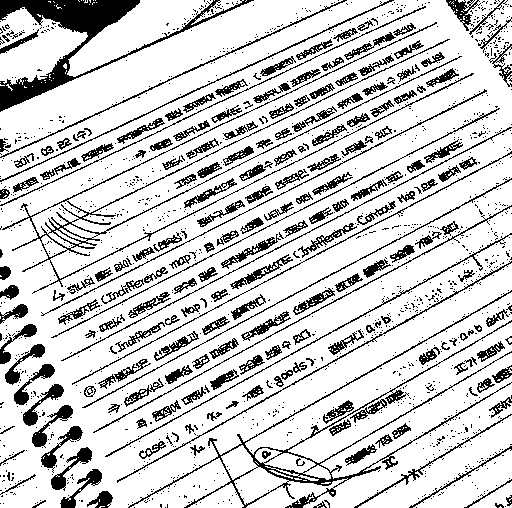

In [ ]:
binary_ad = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 121, 4
)
cv2_imshow(binary_ad)

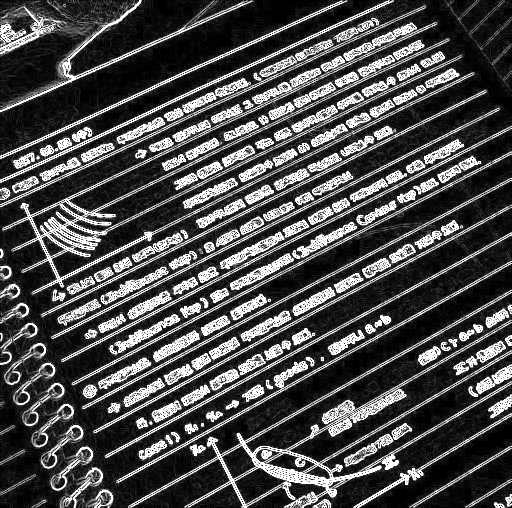

In [ ]:
# 소벨 필터

gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3) # dy=1 -> 가로선

mag = cv2.magnitude(gx, gy)
mag = np.uint8(np.clip(mag, 0, 255))
cv2_imshow(mag)